In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\jyoth\Downloads\Book2.csv")

# --- Check duplicate rows ---
num_duplicates = df.duplicated().sum()
duplicate_rows = df[df.duplicated()]   # actual duplicate rows

print("Number of duplicate rows:", num_duplicates)
print("\nDuplicate rows (first few):")
print(duplicate_rows.head())

# --- Check missing values ---
num_missing = df.isnull().sum().sum()   # total missing values
missing_per_column = df.isnull().sum()  # missing values per column

print("\nTotal missing values:", num_missing)
print("\nMissing values per column:")
print(missing_per_column[missing_per_column > 0])  # only show columns with missing values

# --- Rows with missing values ---
rows_with_missing = df[df.isnull().any(axis=1)]
print("\nRows with missing values (first few):")
print(rows_with_missing.head())

Number of duplicate rows: 6

Duplicate rows (first few):
    Book_ID Book_Title Author_Name    Publisher Book_Category   ISBN_Number  \
39    B2039    Book_39   Author_39  McGraw Hill          Math  2.723315e+09   
103   B2102   Book_102  Author_102     Elsevier   Programming  4.848770e+09   
153   B2152   Book_152  Author_152     Elsevier       Science  5.499431e+09   
161   B2158   Book_158  Author_158  McGraw Hill       Science  6.988252e+09   
162   B2102   Book_102  Author_102     Elsevier   Programming  4.848770e+09   

     Book_Edition Language  Book_Price  Book_Rack_No Book_Availability  \
39            5.0   Telugu      896.52          13.0                No   
103           3.0    Hindi      959.10          44.0               Yes   
153           4.0    Hindi      976.15           7.0               Yes   
161           3.0   Telugu      790.27          10.0               Yes   
162           3.0    Hindi      959.10          44.0               Yes   

    Book_Condition Dama

Number of duplicate rows: 6
Total missing values: 102


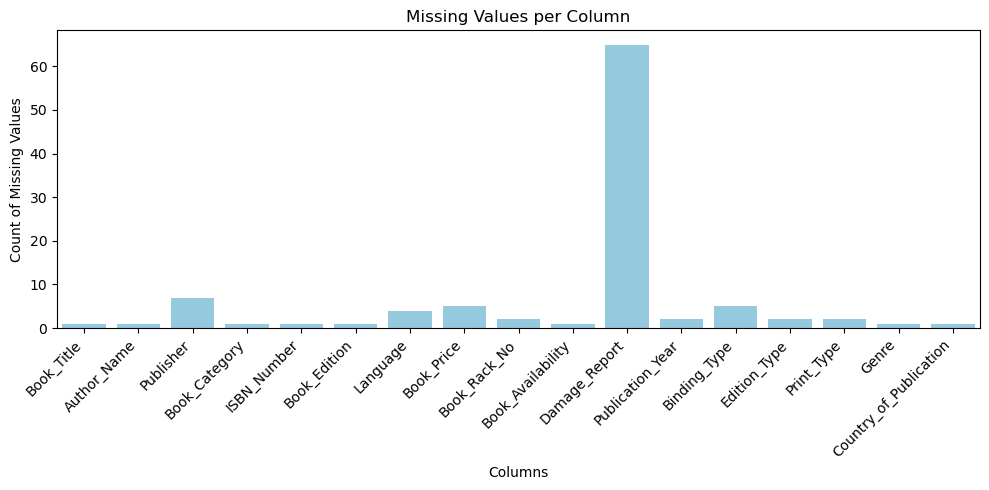

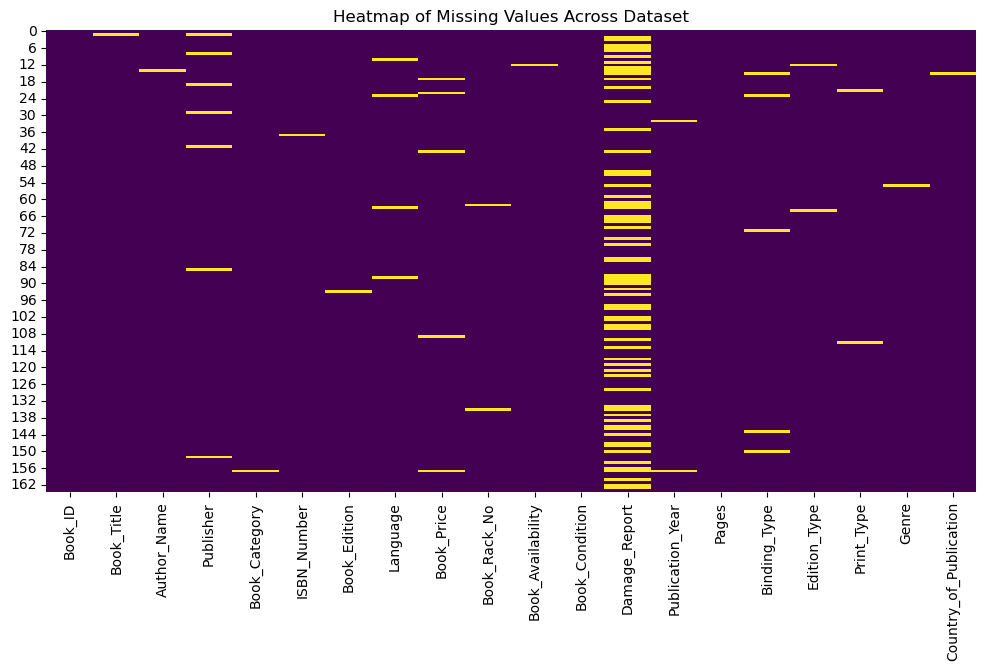

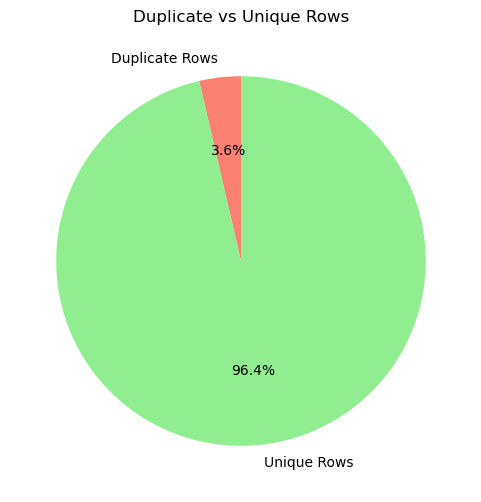

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\jyoth\Downloads\Book2.csv")

# --- Duplicates ---
num_duplicates = df.duplicated().sum()
duplicate_rows = df[df.duplicated()]

print("Number of duplicate rows:", num_duplicates)

# --- Missing values ---
num_missing = df.isnull().sum().sum()
missing_per_column = df.isnull().sum()

print("Total missing values:", num_missing)

# -----------------------------
# Graphical Representation
# -----------------------------

# 1. Bar chart of missing values per column
missing_counts = missing_per_column[missing_per_column > 0]
plt.figure(figsize=(10,5))
sns.barplot(x=missing_counts.index, y=missing_counts.values, color="skyblue")
plt.title("Missing Values per Column")
plt.ylabel("Count of Missing Values")
plt.xlabel("Columns")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2. Heatmap of missing values across dataset
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap of Missing Values Across Dataset")
plt.show()

# 3. Pie chart of duplicate vs unique rows
labels = ["Duplicate Rows", "Unique Rows"]
sizes = [num_duplicates, len(df) - num_duplicates]
colors = ["salmon", "lightgreen"]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Duplicate vs Unique Rows")
plt.show()

In [11]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\jyoth\Downloads\Book2.csv")

# Replace empty strings with NaN first
df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)

# Fill missing values: numeric → 0, non-numeric → "NULL"
df = df.fillna({
    'Book_ID': 0,
    'ISBN_Number': 0,
    'Book_Edition': 0,
    'Book_Price': 0,
    'Book_Rack_No': 0,
    'Publication_Year': 0,
    'Pages': 0,
    'Book_Title': "NULL",
    'Author_Name': "NULL",
    'Publisher': "NULL",
    'Book_Category': "NULL",
    'Language': "NULL",
    'Book_Availability': "NULL",
    'Book_Condition': "NULL",
    'Damage_Report': "NULL",
    'Binding_Type': "NULL",
    'Edition_Type': "NULL",
    'Print_Type': "NULL",
    'Genre': "NULL",
    'Country_of_Publication': "NULL"
})

# Remove duplicate rows
df = df.drop_duplicates()

# Show results
print("Number of duplicate rows (after cleaning):", df.duplicated().sum())
print("Total missing values (after cleaning):", df.isnull().sum().sum())

# Save cleaned dataset
output_path = r"C:\Users\jyoth\Downloads\data3.csv"
df.to_csv(output_path, index=False)
print("✅ Cleaned dataset saved to:", output_path)

Number of duplicate rows (after cleaning): 0
Total missing values (after cleaning): 0
✅ Cleaned dataset saved to: C:\Users\jyoth\Downloads\data3.csv


Any nulls left?: False
Duplicate rows: 0
Shape of cleaned dataset: (159, 20)


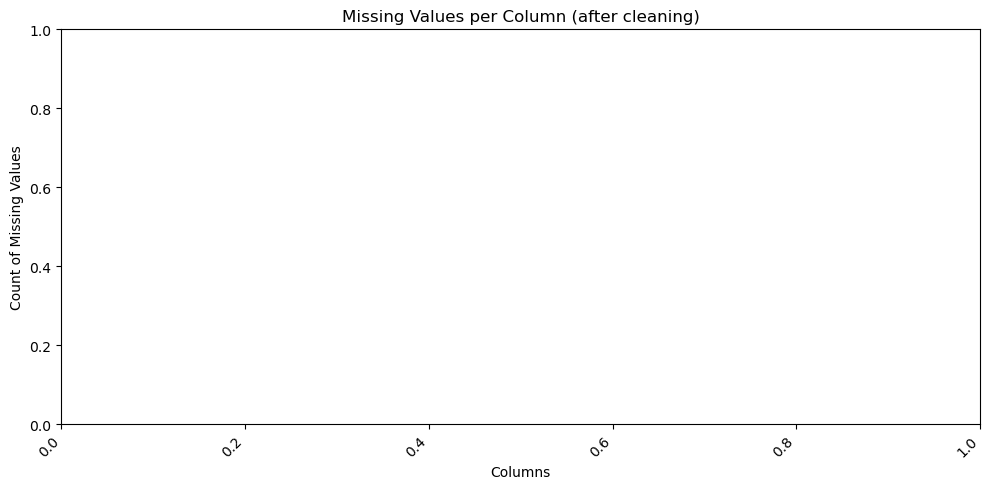

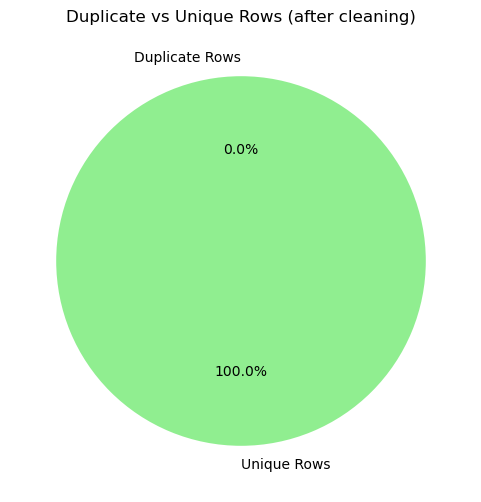

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\jyoth\Downloads\Book2.csv")

# Step 1: Replace empty strings with NaN
df.replace("", pd.NA, inplace=True)

# Step 2: Fill NaN values with 0
df = df.fillna(0)

# Step 3: Remove duplicates
df = df.drop_duplicates()

# --- Verification ---
print("Any nulls left?:", df.isnull().values.any())
print("Duplicate rows:", df.duplicated().sum())
print("Shape of cleaned dataset:", df.shape)

# --- Graphical Representation ---

# 1. Bar chart of missing values per column (should be empty now)
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(10,5))
sns.barplot(x=missing_counts.index, y=missing_counts.values, color="skyblue")
plt.title("Missing Values per Column (after cleaning)")
plt.ylabel("Count of Missing Values")
plt.xlabel("Columns")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2. Pie chart of duplicate vs unique rows
labels = ["Duplicate Rows", "Unique Rows"]
sizes = [df.duplicated().sum(), len(df) - df.duplicated().sum()]
colors = ["salmon", "lightgreen"]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Duplicate vs Unique Rows (after cleaning)")
plt.show()